In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import os
import pickle

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from adaptive_smc.save_and_read_and_postprocess import acf2, correct_acf, acf


PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR + file, "rb"))
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [2]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'pCN',
'build_gaussian_rwmh_cov_proposal_gamma' : 'adaptive RW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"ARW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}
print(idx_proposal)

{'pCN': [0]}


In [4]:
PKLs[0]['res'][3]

Array([[[0.     ],
        [0.2495 ],
        [0.1055 ],
        [0.12476]]], dtype=float16)

(array([1.000e+00, 0.000e+00, 0.000e+00, 9.200e+01, 2.600e+01, 7.670e+02,
        6.200e+01, 1.171e+03, 1.825e+03, 1.176e+03, 1.548e+03, 1.250e+02,
        9.800e+01, 4.260e+02, 5.900e+01, 0.000e+00, 1.120e+02, 0.000e+00,
        4.990e+02, 2.100e+01]),
 array([0.91992188, 1.23046875, 1.54003906, 1.84960938, 2.16015625,
        2.47070312, 2.78125   , 3.08984375, 3.40039062, 3.7109375 ,
        4.01953125, 4.33203125, 4.640625  , 4.94921875, 5.26171875,
        5.5703125 , 5.8828125 , 6.19140625, 6.5       , 6.8125    ,
        7.12109375]),
 <BarContainer object of 20 artists>)

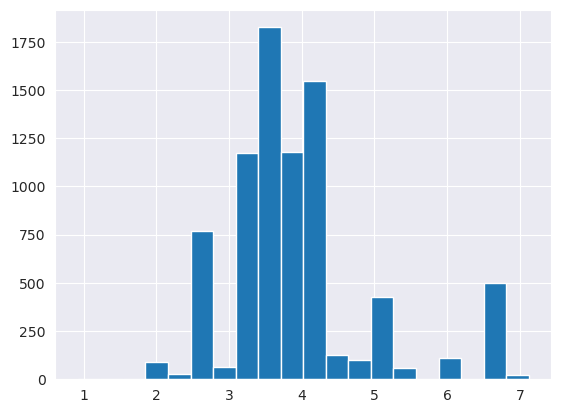

In [17]:
plt.hist(PKLs[0]['res'][0][0, -1, 0].reshape((-1, 100))[:,4], bins=20)

In [15]:
PKLs[0]['res'][0][0, -1, 0].reshape((-1, 100)).shape

(8008, 100)